# Corporate Insolvency in India: The Intangible Asset Illusion & Forensic Modeling

## Summary
The Indian corporate landscape has witnessed spectacular financial collapses,from Kingfisher Airlines to the Amtek Auto group. Traditional financial screeners often miss these events because they rely on easily manipulated metrics like Net Income or top-line revenue. 

This project builds a predictive insolvency model (Random Forest) focused on forensic accounting indicators. Rather than just looking at negative profitability, we are testing specific failure signatures:
1. **The Intangible Asset Illusion:** Distressed companies frequently inflate their balance sheets using heavily impaired "intangible assets" or "goodwill" to secure leverage, masking an underlying negative net worth.
2. **The Working Capital Trap:** A severe divergence between reported EBITDA (paper profit) and Operating Cash Flow (actual liquidity), usually driven by uncollectible receivables.
3. **The Debt Avalanche:** Capital structures overly reliant on short-term borrowings to fund long-term, depreciating assets, leading to sudden liquidity crises when credit markets tighten.

## The Dataset
We are utilizing `insolvency_raw.csv`, a dataset containing ~400 Indian listed companies. Crucially, the "bankrupt" class (Target = 1) features a curated list of corporate insolvencies gathered through standard financial platforms (such as Yahoo Finance, Screener, and Investing.com). This data is fortified by rigorous manual vetting of company annual reports from the fiscal years immediately preceding their collapse, capturing their financial state at the exact moment the terminal distress became mathematically irreversible.

## Dataset Features

### Metadata Fields
- `ticker`: Stock ticker symbol (e.g., RELIANCE, TCS)
- `company_name`: Legal company name
- `sector`: Industry sector
- `industry`: Industry classification
- `fiscal_year`: Financial year of data
- `currency`: Currency of financial values (INR)
- `source_url`: Where the data was sourced from
- `extraction_status`: Data collection status
- `extraction_error`: Any errors during data extraction

### Financial Features (Key Indicators)
- `market_cap`: Market capitalization
- `total_debt`: Total debt outstanding
- `intangible_assets`: Goodwill and intangible assets
- `cash_and_equivalents`: Cash on hand
- `current_liabilities`: Short-term obligations
- `operating_cash_flow`: Cash generated from operations
- `ebitda`: Earnings before interest, tax, depreciation, amortization
- `interest_expense`: Interest paid on debt
- `net_income`: Profit/loss for the period
- `total_assets`: Total resources controlled by company

### Target Variable
- `target`: 1 (Insolvent/Bankrupt), 0 (Healthy/Solvent)

### Environment Setup

In [1]:
# Import core libraries
import pandas as pd
import numpy as np
import re

# Import visualization libraries
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# Import modeling utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    make_scorer,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Configure display and warnings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
import warnings
warnings.filterwarnings('ignore')


print('Environment initialized.')

Environment initialized.


## Data Cleaning & Imputation

In [2]:
# Load raw data and inspect initial state
df_raw = pd.read_csv('insolvency_raw.csv', low_memory=False)

print(f"Raw shape = {df_raw.shape}")
display(df_raw.info())

# Check class balance
print('Target distribution')
print(df_raw['target'].value_counts(normalize=True, dropna=False))

# Inspect duplicate tickers
dupes = df_raw[df_raw.duplicated(subset=['ticker'], keep=False)]
print(f"Duplicate-ticker rows = {len(dupes)}")
if len(dupes) > 0:
    display(dupes[['ticker', 'company_name', 'extraction_status']].sort_values('ticker').head())

Raw shape = (431, 21)
<class 'pandas.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ticker                431 non-null    str    
 1   company_name          431 non-null    str    
 2   sector                385 non-null    str    
 3   industry              385 non-null    str    
 4   business_summary      385 non-null    str    
 5   target                431 non-null    int64  
 6   market_cap            398 non-null    str    
 7   total_debt            396 non-null    str    
 8   intangible_assets     392 non-null    str    
 9   cash_and_equivalents  398 non-null    str    
 10  current_liabilities   398 non-null    str    
 11  operating_cash_flow   398 non-null    str    
 12  ebitda                396 non-null    str    
 13  interest_expense      397 non-null    str    
 14  net_income            397 non-null    str    
 15  total_assets

None

Target distribution
target
0   0.65
1   0.35
Name: proportion, dtype: float64
Duplicate-ticker rows = 47


,ticker,company_name,extraction_status
375,ALOKINDS,Alok Industries Ltd,success_manual
290,ALOKINDS,ALOK INDUSTRIES LIMITED,yfinance
36,ANSALAPI,Ansal Properties & Infrastructure,yfinance
266,ANSALAPI,ANSAL PROP & INFRA LTD,Success_Manual
32,ARSSINFRA,ARSS Infrastructure Projects,yfinance


## Cleaning Execution

From this point onward, we apply transformations to fix the issues diagnosed in cells 6 to 10.

Cleaning goals:
- Preserve key identifier columns (`ticker`, `company_name`, `target`)
- Standardize text and URL formats
- Convert numeric fields from comma-formatted strings to numeric dtype
- Resolve duplicate tickers using data completeness
- Handle missing values in financial columns
- Validate dataset integrity before EDA

In [3]:
# Create a working copy and define financial columns
df = df_raw.copy()

financial_cols = ['market_cap', 'total_debt', 'intangible_assets', 'cash_and_equivalents',
                  'current_liabilities', 'operating_cash_flow', 'ebitda', 'interest_expense',
                  'net_income', 'total_assets']

# Standardize text fields while preserving missing values
for col in ['company_name', 'sector', 'industry', 'extraction_status']:
    df[col] = df[col].astype('string').str.strip()

df['sector'] = df['sector'].str.title()
df['industry'] = df['industry'].str.title()
df['extraction_status'] = df['extraction_status'].str.upper()


def normalize_url(url):
    if pd.isna(url):
        return np.nan
    s = str(url).strip()
    if s == '' or s.lower() in {'nan', 'none', 'null', 'n/a'}:
        return np.nan

    # Remove whitespace/protocol artifacts and enforce clean https URLs.
    s = re.sub(r'\s+', '', s)
    s = s.replace('yahoo://', '')
    s = re.sub(r'^(https?://)+', 'https://', s)

    if s.startswith('http://'):
        s = 'https://' + s[len('http://'):]
    elif not s.startswith('https://'):
        s = 'https://' + s.lstrip('/')

    return s

df['source_url'] = df['source_url'].apply(normalize_url)

# Normalize numeric fields
for col in financial_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

df['fiscal_year'] = pd.to_numeric(df['fiscal_year'], errors='coerce').astype('Int64')

# Remove low-quality rows
rows_start = len(df)
metadata_only_mask = df['extraction_status'].fillna('').str.contains('METADATA_ONLY', na=False)
df = df[~metadata_only_mask].copy()
removed_metadata_only = int(metadata_only_mask.sum())

missing_ratio = df[financial_cols].isnull().sum(axis=1) / len(financial_cols)
high_missing_mask = missing_ratio > 0.5
df = df[~high_missing_mask].copy()
removed_high_missing = int(high_missing_mask.sum())

# Resolve duplicate tickers by completeness, then fiscal recency
df['missing_count'] = df[financial_cols].isnull().sum(axis=1)
df['_fiscal_sort'] = pd.to_numeric(df['fiscal_year'], errors='coerce')

df = (
    df.sort_values(['ticker', 'missing_count', '_fiscal_sort'], ascending=[True, True, False])
      .drop_duplicates(subset=['ticker'], keep='first')
      .drop(columns=['missing_count', '_fiscal_sort'])
      .reset_index(drop=True)
)

df['intangible_assets'] = df['intangible_assets'].fillna(0)

# Apply strict completeness rule to financial fields
rows_before_strict = len(df)
df = df.dropna(subset=financial_cols, how='any').copy()
rows_dropped_strict = rows_before_strict - len(df)

# Final text cleanup
df['extraction_error'] = df['extraction_error'].fillna('')

print(f"Cleaned shape = {df.shape}")
print(f"Rows removed (metadata_only) = {removed_metadata_only}")
print(f"Rows removed (>50% missing financial) = {removed_high_missing}")
print(f"Rows removed (strict financial completeness) = {rows_dropped_strict}")
print(f"Total rows removed = {rows_start - len(df)}")

Cleaned shape = (371, 21)
Rows removed (metadata_only) = 33
Rows removed (>50% missing financial) = 1
Rows removed (strict financial completeness) = 2
Total rows removed = 60


In [4]:
# Save cleaned dataset
output_path = 'insolvency_clean.csv'

df.to_csv(output_path, index=False)

# Build before-vs-after quality summary
summary = pd.DataFrame({
    'metric': [
        'rows',
        'columns',
        'duplicate_ticker_rows',
        'financial_missing_values',
        'unique_tickers'
    ],
    'before': [
        len(df_raw),
        len(df_raw.columns),
        int(df_raw.duplicated(subset=['ticker'], keep=False).sum()) if 'ticker' in df_raw.columns else np.nan,
        int(df_raw[financial_cols].isnull().sum().sum()),
        int(df_raw['ticker'].nunique()) if 'ticker' in df_raw.columns else np.nan
    ],
    'after': [
        len(df),
        len(df.columns),
        int(df.duplicated(subset=['ticker'], keep=False).sum()),
        int(df[financial_cols].isnull().sum().sum()),
        int(df['ticker'].nunique())
    ]
})

print('Cleaning summary')
print(summary)
print(f"Saved cleaned file = {output_path}")

Cleaning summary
                     metric  before  after
0                      rows     431    371
1                   columns      21     21
2     duplicate_ticker_rows      47      0
3  financial_missing_values     343      0
4            unique_tickers     406    371
Saved cleaned file = insolvency_clean.csv


## Exploratory Data Analysis


### 1: Dataset Snapshot
Quick sanity checks after cleaning: shape, class balance, extraction status mix, and basic numeric summary.

Cleaned shape = (371, 21)
Target counts
target
0    251
1    120
Name: count, dtype: int64
Extraction status counts
extraction_status
YFINANCE          296
SUCCESS_MANUAL     75
Name: count, dtype: Int64


,count,mean,std,min,25%,50%,75%,max
market_cap,371.00,618375607140.52,1468495582251.33,0.00,2596774784.00,133801263104.00,609450786816.00,17796553506816.00
total_debt,371.00,107215487896.96,361126582127.98,0.00,1786240312.00,10075300000.00,40536116000.00,3695750000000.00
intangible_assets,371.00,36723076972.78,243205141139.53,0.00,27660000.00,1015200000.00,9190250000.00,4089390000000.00
cash_and_equivalents,371.00,38162680620.02,142593988030.87,0.00,850456500.00,7260420000.00,29843500000.00,2387920000000.00
current_liabilities,371.00,115886901741.10,346604775468.08,6221000.00,8493277000.00,26345100000.00,72516881500.00,4537370000000.00
operating_cash_flow,371.00,33976176464.32,131018308811.63,-171696500000.00,661270039.50,5404290000.00,18454695000.00,1787030000000.00
ebitda,371.00,46598661203.34,144538781947.73,-68000000000.00,1337245000.00,8970100000.00,28032550000.00,1812740000000.00
interest_expense,371.00,7443725218.17,24492217793.86,-60800000.00,169456500.00,723500000.00,3642612500.00,243143000000.00
net_income,371.00,19383752586.30,66419666553.60,-273834000000.00,12747730.00,3848000000.00,14590800000.00,696480000000.00
total_assets,371.00,370258805632.93,1277250707682.95,20340000.00,27545225000.00,77176700000.00,211903528388.00,19501210000000.00


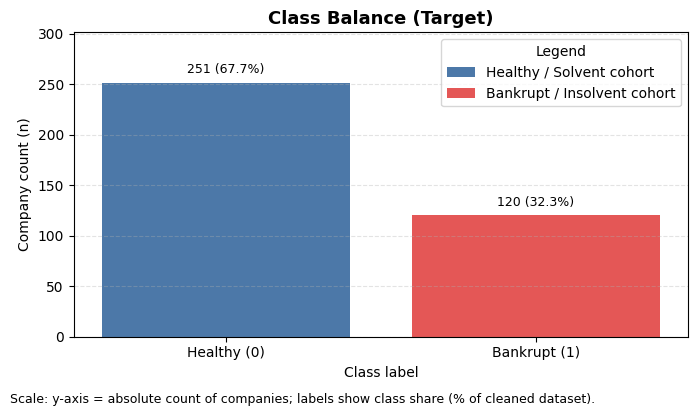

Class imbalance = 67.7% healthy vs 32.3% bankrupt


In [4]:
# Load cleaned data if not already in memory
if 'df' not in globals():
    df = pd.read_csv('insolvency_clean.csv', low_memory=False)

# Print core dataset checks
print(f"Cleaned shape = {df.shape}")
print('Target counts')
target_counts = df['target'].value_counts(dropna=False).sort_index()
print(target_counts)

print('Extraction status counts')
if 'extraction_status' in df.columns:
    print(df['extraction_status'].fillna('MISSING').value_counts().head(10))

numeric_cols = [
    'market_cap', 'total_debt', 'intangible_assets', 'cash_and_equivalents',
    'current_liabilities', 'operating_cash_flow', 'ebitda', 'interest_expense',
    'net_income', 'total_assets'
]
available_numeric = [c for c in numeric_cols if c in df.columns]

display(df[available_numeric].describe().T)


label_map = {0: 'Healthy (0)', 1: 'Bankrupt (1)'}
color_map = {0: '#4C78A8', 1: '#E45756'}
plot_df = target_counts.rename_axis('target').reset_index(name='count')
plot_df['label'] = plot_df['target'].map(label_map)
plot_df['pct'] = (plot_df['count'] / len(df)) * 100

# Plot class balance with count and share labels
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    plot_df['label'],
    plot_df['count'],
    color=[color_map[t] for t in plot_df['target']],
)

ax.set_title('Class Balance (Target)', fontsize=13, weight='bold')
ax.set_xlabel('Class label')
ax.set_ylabel('Company count (n)')
ax.set_ylim(0, max(plot_df['count']) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.35)

for bar, pct in zip(bars, plot_df['pct']):
    height = bar.get_height()
    ax.annotate(
        f"{int(height)} ({pct:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
    )

legend_handles = [
    Patch(facecolor=color_map[0], label='Healthy / Solvent cohort'),
    Patch(facecolor=color_map[1], label='Bankrupt / Insolvent cohort'),
]
ax.legend(handles=legend_handles, title='Legend', loc='upper right', frameon=True)

fig.text(
    0.01,
    -0.02,
    'Scale: y-axis = absolute count of companies; labels show class share (% of cleaned dataset).',
    fontsize=9,
 )
plt.tight_layout()
plt.show()

bankrupt_pct = (target_counts.get(1, 0) / len(df)) * 100
healthy_pct = (target_counts.get(0, 0) / len(df)) * 100
print(f"Class imbalance = {healthy_pct:.1f}% healthy vs {bankrupt_pct:.1f}% bankrupt")

### 2: Missingness and Data Quality
Assess any residual missing values and compare missingness between bankrupt and healthy cohorts.

Top columns by missing percentage


,column,missing_pct
0,sector,2.96
1,business_summary,2.96
2,industry,2.96
3,ticker,0.00
4,company_name,0.00
5,target,0.00
6,market_cap,0.00
7,total_debt,0.00
8,intangible_assets,0.00
9,cash_and_equivalents,0.00


Missing percentage in numeric features by target


target,0,1
market_cap,0.00,0.00
total_debt,0.00,0.00
intangible_assets,0.00,0.00
cash_and_equivalents,0.00,0.00
current_liabilities,0.00,0.00
operating_cash_flow,0.00,0.00
ebitda,0.00,0.00
interest_expense,0.00,0.00
net_income,0.00,0.00
total_assets,0.00,0.00


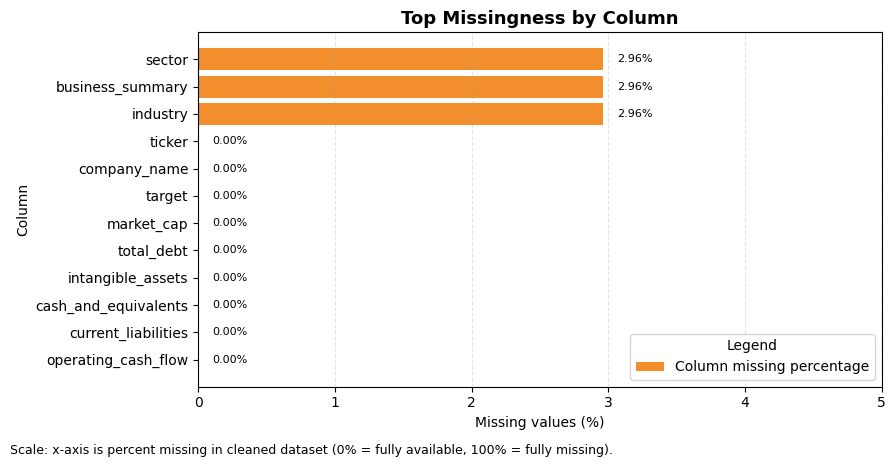

In [5]:
# Compute and display missingness overview
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = missing_pct.reset_index()
missing_table.columns = ['column', 'missing_pct']

print('Top columns by missing percentage')
display(missing_table.head(12))

# Compare missingness by class for numeric features
if 'target' in df.columns:
    target_missing = (
        df.groupby('target')[available_numeric]
          .apply(lambda g: g.isna().mean() * 100)
          .T
    )
    print('Missing percentage in numeric features by target')
    display(target_missing)

# Plot top-missing columns
top_missing = missing_table.head(12).copy()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(
    top_missing['column'][::-1],
    top_missing['missing_pct'][::-1],
    color='#F28E2B'
)
ax.set_title('Top Missingness by Column', fontsize=13, weight='bold')
ax.set_xlabel('Missing values (%)')
ax.set_ylabel('Column')
ax.set_xlim(0, max(5.0, float(top_missing['missing_pct'].max()) * 1.15))
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.legend(
    handles=[Patch(facecolor='#F28E2B', label='Column missing percentage')],
    title='Legend',
    loc='lower right',
    frameon=True,
)

for y_pos, val in enumerate(top_missing['missing_pct'][::-1]):
    ax.text(val + 0.1, y_pos, f'{val:.2f}%', va='center', fontsize=8)

fig.text(
    0.01,
    -0.02,
    'Scale: x-axis is percent missing in cleaned dataset (0% = fully available, 100% = fully missing).',
    fontsize=9,
)
plt.tight_layout()
plt.show()

max_missing_col = missing_table.iloc[0]['column']
max_missing_val = float(missing_table.iloc[0]['missing_pct'])

### 3: Forensic Signal Exploration
Build ratio features and compare their distributions by target to inspect insolvency signatures.

Ratio medians by target


target,0,1
intangibles_to_assets,0.02,0.00
debt_to_assets,0.09,0.51
cash_to_current_liabilities,0.53,0.03
ocf_to_ebitda,0.70,0.31
interest_coverage_proxy,20.02,0.65
ocf_ni_divergence,1292767000.00,755962500.00
tangible_asset_coverage,9.56,1.92


Scaling clip bounds (1%, 99%)


,feature,clip_1pct,clip_99pct
0,intangibles_to_assets,0.00,0.61
1,debt_to_assets,0.00,12.88
2,cash_to_current_liabilities,0.00,5.20
3,ocf_to_ebitda,-13.22,7.47
4,interest_coverage_proxy,-34.31,1277.97
5,ocf_ni_divergence,-77978440000.00,299116430000.00
6,tangible_asset_coverage,0.08,2351.52


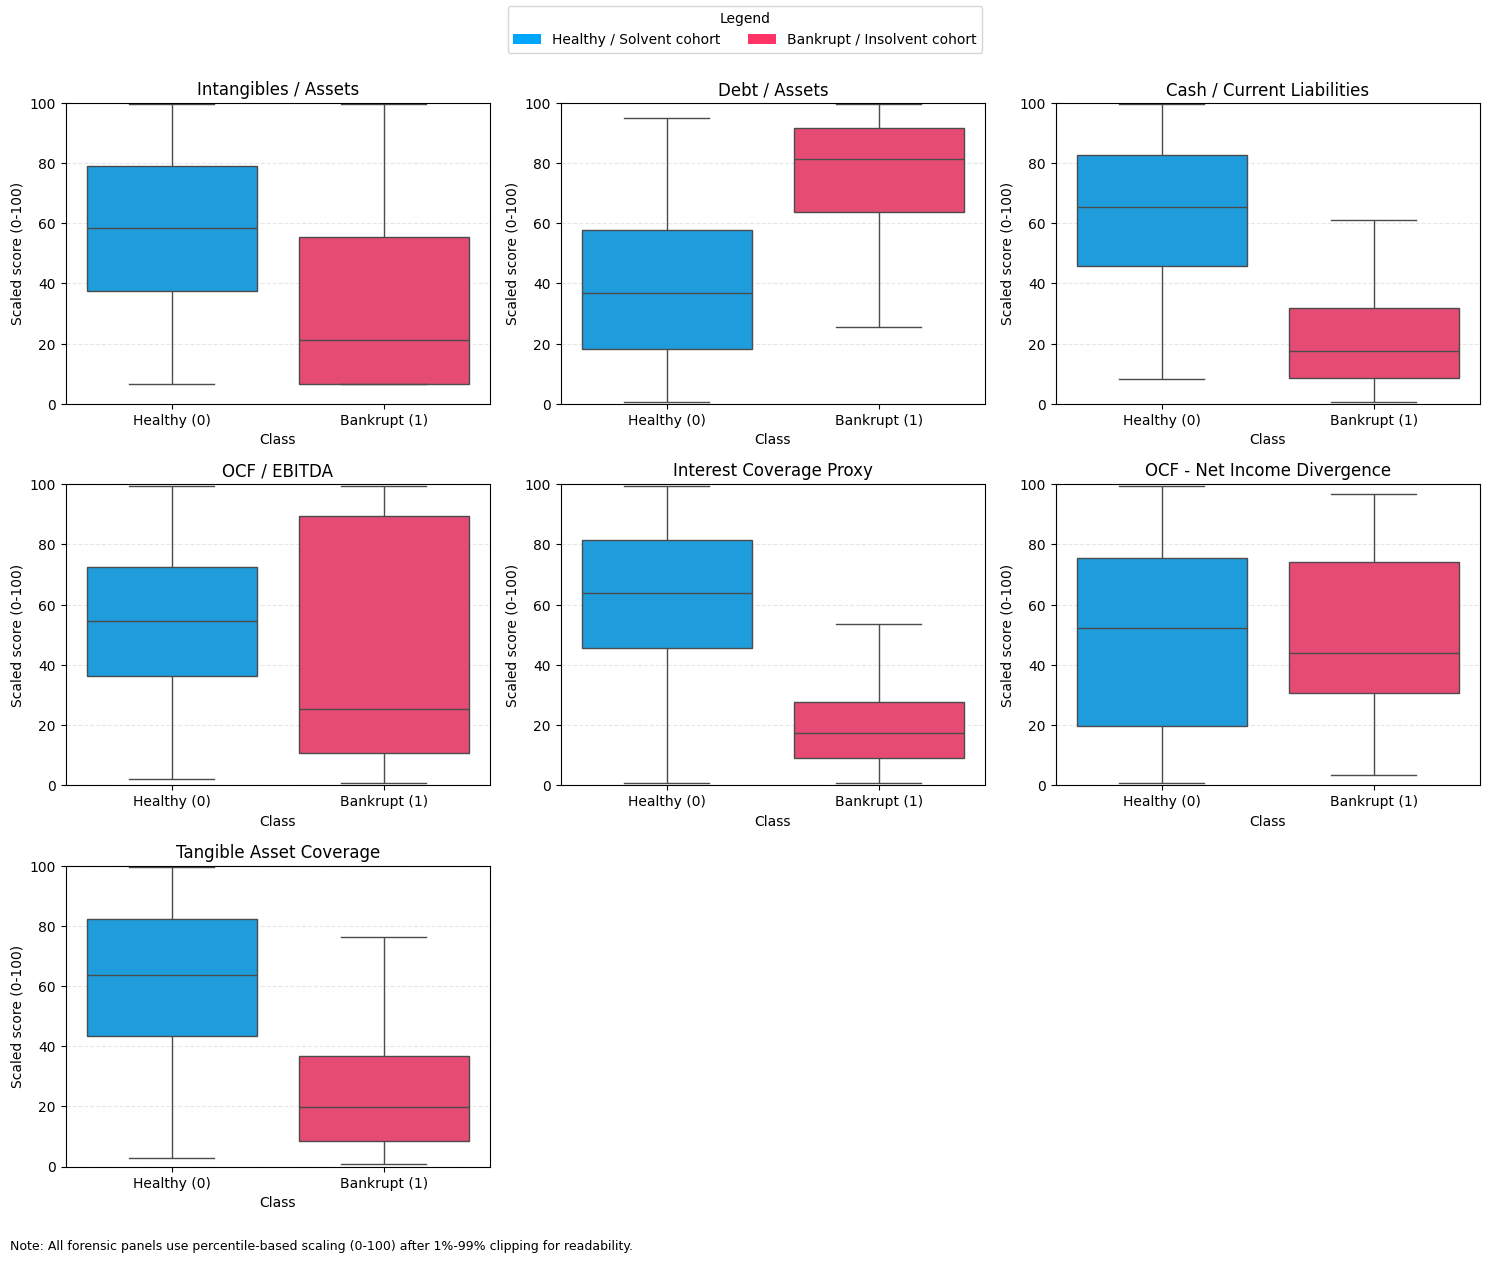

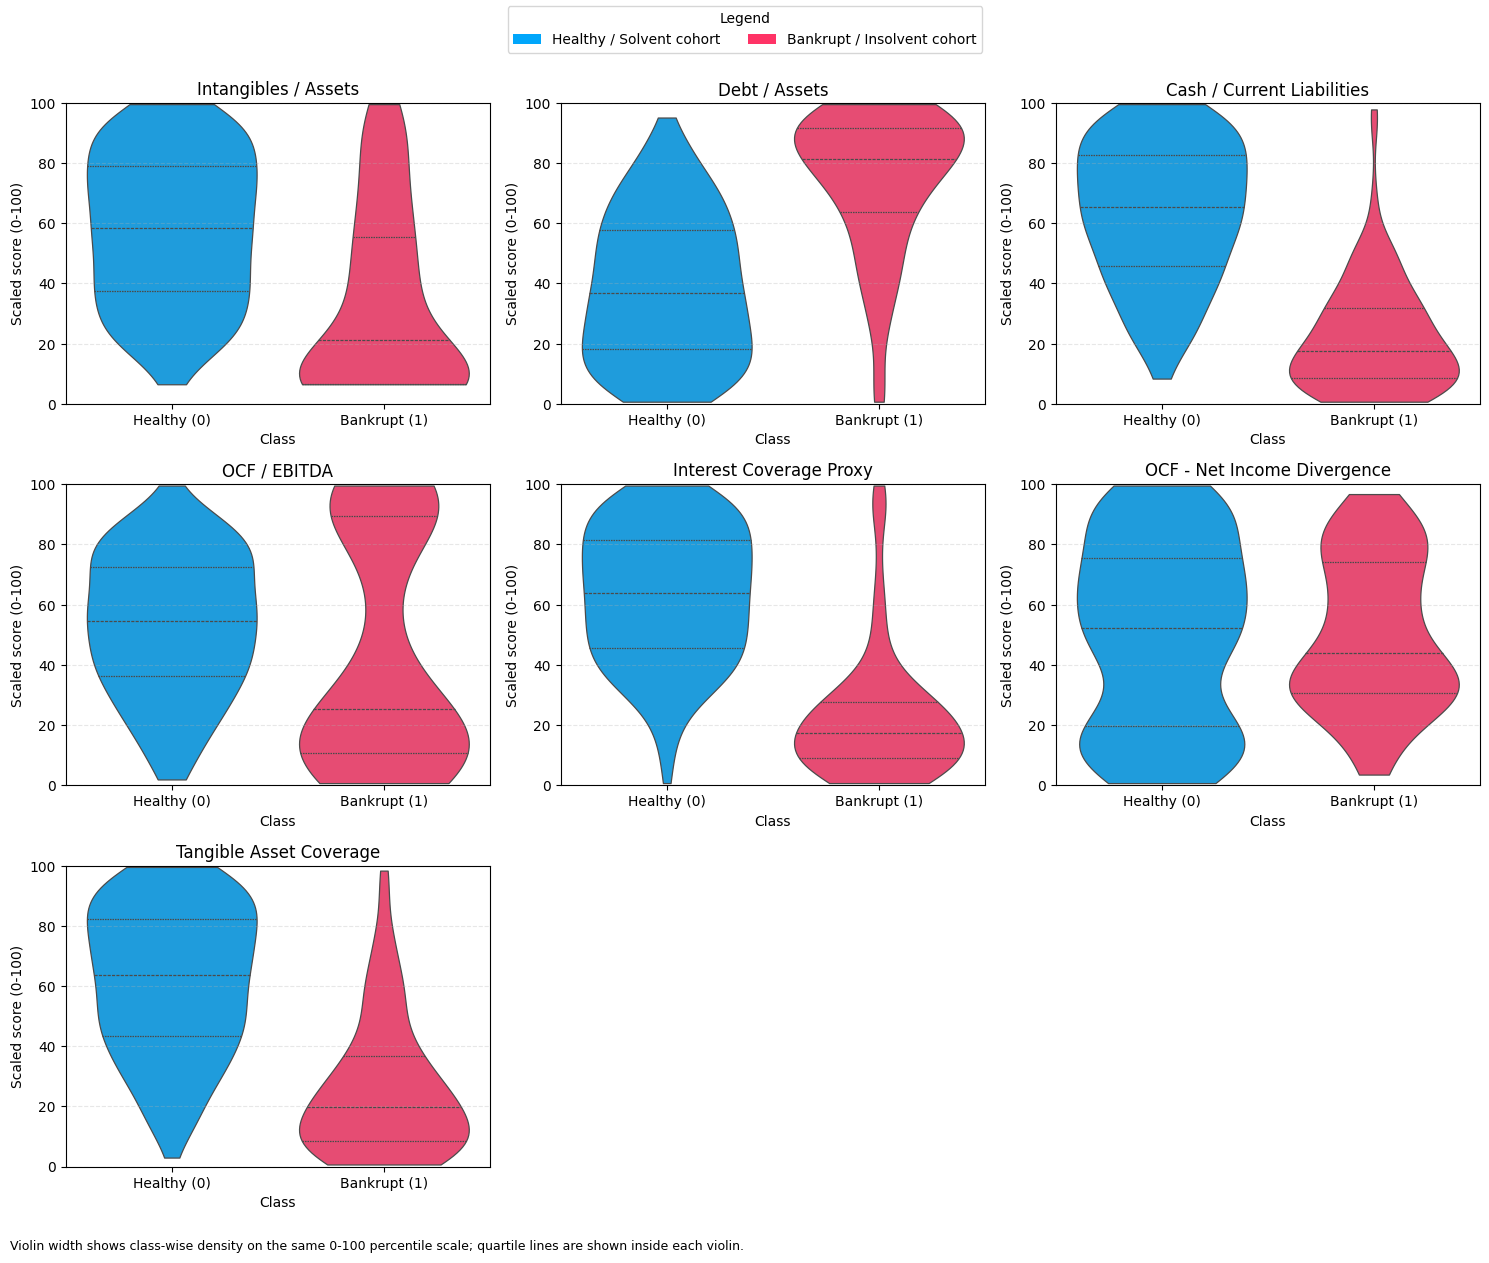

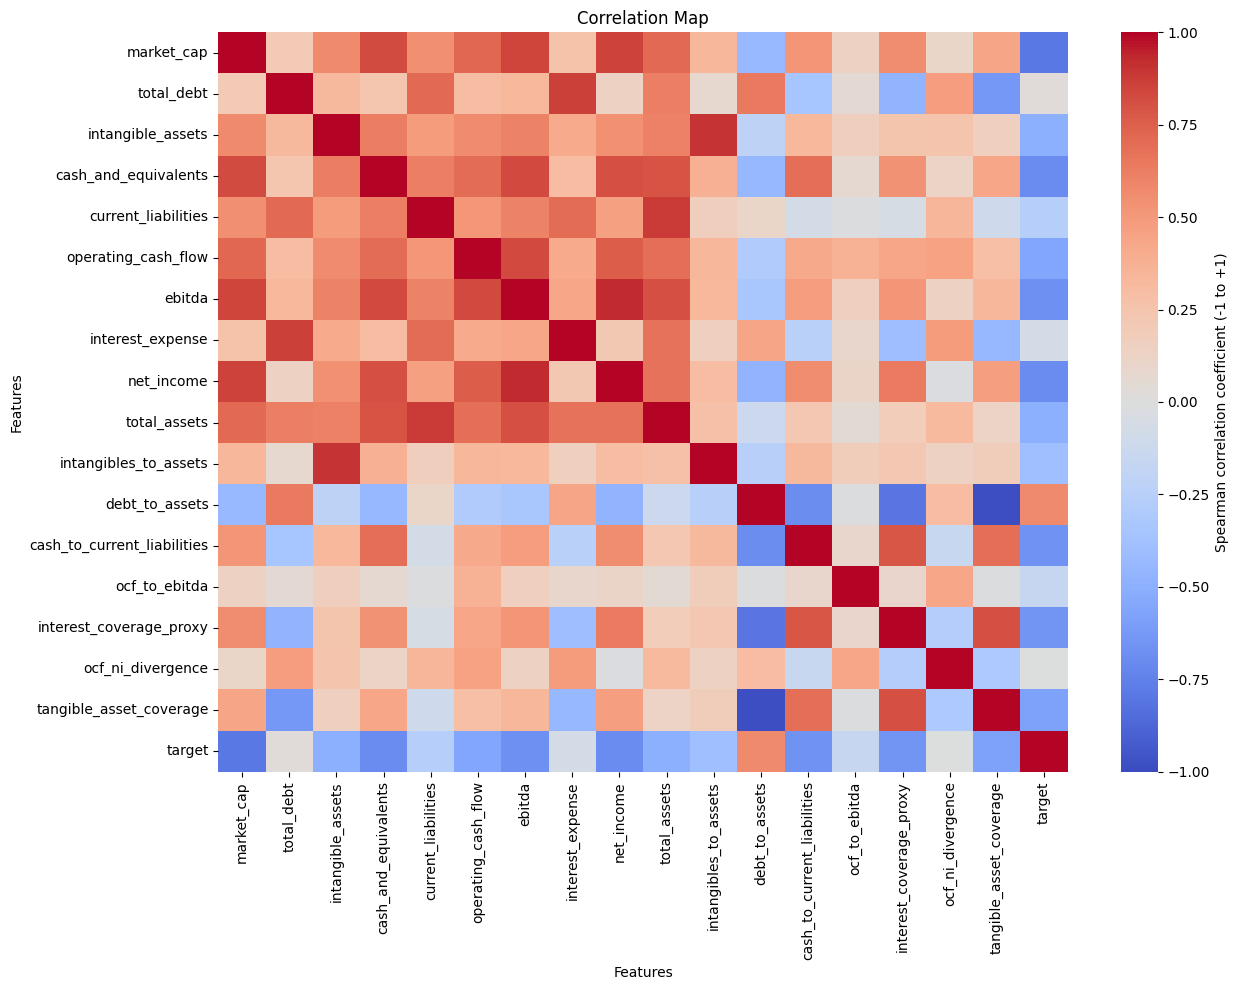

In [8]:
# Build forensic ratio features
eda = df.copy()

eda['intangibles_to_assets'] = eda['intangible_assets'] / eda['total_assets'].replace(0, np.nan)
eda['debt_to_assets'] = eda['total_debt'] / eda['total_assets'].replace(0, np.nan)
eda['cash_to_current_liabilities'] = eda['cash_and_equivalents'] / eda['current_liabilities'].replace(0, np.nan)
eda['ocf_to_ebitda'] = eda['operating_cash_flow'] / eda['ebitda'].replace(0, np.nan)
eda['interest_coverage_proxy'] = eda['ebitda'] / eda['interest_expense'].replace(0, np.nan)
eda['ocf_ni_divergence'] = eda['operating_cash_flow'] - eda['net_income']
eda['tangible_asset_coverage'] = (eda['total_assets'] - eda['intangible_assets']) / eda['total_debt'].replace(0, np.nan)

ratio_cols = [
    'intangibles_to_assets',
    'debt_to_assets',
    'cash_to_current_liabilities',
    'ocf_to_ebitda',
    'interest_coverage_proxy',
    'ocf_ni_divergence',
    'tangible_asset_coverage',
]

print('Ratio medians by target')
ratio_medians = eda.groupby('target')[ratio_cols].median().T
display(ratio_medians)

target_label_map = {0: 'Healthy (0)', 1: 'Bankrupt (1)'}
palette = {'Healthy (0)': '#00A6FB', 'Bankrupt (1)': '#FF3366'}
eda['target_label'] = eda['target'].map(target_label_map)

# Winsorize and map each ratio to a 0-100 percentile scale
readable_cols = ratio_cols.copy()
readable_clip_bounds = {}

for col in readable_cols:
    s = eda[col].replace([np.inf, -np.inf], np.nan)
    lo, hi = s.quantile([0.01, 0.99])
    clipped = s.clip(lower=lo, upper=hi)
    eda[f'{col}_prank'] = clipped.rank(method='average', pct=True) * 100
    readable_clip_bounds[col] = (lo, hi)

print('Scaling clip bounds (1%, 99%)')
display(
    pd.DataFrame(
        [
            {'feature': c, 'clip_1pct': readable_clip_bounds[c][0], 'clip_99pct': readable_clip_bounds[c][1]}
            for c in readable_cols
        ]
    )
)

display_name = {
    'intangibles_to_assets': 'Intangibles / Assets',
    'debt_to_assets': 'Debt / Assets',
    'cash_to_current_liabilities': 'Cash / Current Liabilities',
    'ocf_to_ebitda': 'OCF / EBITDA',
    'interest_coverage_proxy': 'Interest Coverage Proxy',
    'ocf_ni_divergence': 'OCF - Net Income Divergence',
    'tangible_asset_coverage': 'Tangible Asset Coverage',
}

# Plot class-wise forensic distributions on the scaled axis (boxplots)
n_plots = len(ratio_cols)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, col in enumerate(ratio_cols):
    y_col = f'{col}_prank'
    panel_title = display_name.get(col, col)

    sns.boxplot(
        data=eda,
        x='target_label',
        y=y_col,
        order=['Healthy (0)', 'Bankrupt (1)'],
        palette=palette,
        showfliers=False,
        ax=axes[idx],
    )
    axes[idx].set_title(panel_title)
    axes[idx].set_xlabel('Class')
    axes[idx].set_ylabel('Scaled score (0-100)')
    axes[idx].set_ylim(0, 100)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.3)

for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

legend_handles = [
    Patch(facecolor=palette['Healthy (0)'], label='Healthy / Solvent cohort'),
    Patch(facecolor=palette['Bankrupt (1)'], label='Bankrupt / Insolvent cohort'),
]
fig.legend(handles=legend_handles, title='Legend', loc='upper center', ncol=2, frameon=True)
fig.text(
    0.01,
    0.01,
    'Note: All forensic panels use percentile-based scaling (0-100) after 1%-99% clipping for readability.',
    fontsize=9,
)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Complement with violin plots to reveal class-wise density shape
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, col in enumerate(ratio_cols):
    y_col = f'{col}_prank'
    panel_title = display_name.get(col, col)

    sns.violinplot(
        data=eda,
        x='target_label',
        y=y_col,
        order=['Healthy (0)', 'Bankrupt (1)'],
        palette=palette,
        cut=0,
        inner='quartile',
        linewidth=0.9,
        ax=axes[idx],
    )
    axes[idx].set_title(panel_title)
    axes[idx].set_xlabel('Class')
    axes[idx].set_ylabel('Scaled score (0-100)')
    axes[idx].set_ylim(0, 100)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.3)

for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

fig.legend(handles=legend_handles, title='Legend', loc='upper center', ncol=2, frameon=True)
fig.text(
    0.01,
    0.01,
    'Violin width shows class-wise density on the same 0-100 percentile scale; quartile lines are shown inside each violin.',
    fontsize=9,
)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Plot Spearman correlation heatmap across raw and engineered features
corr_cols = available_numeric + ratio_cols
spearman_corr = eda[corr_cols + ['target']].corr(method='spearman', numeric_only=True)
plt.figure(figsize=(13, 10))
sns.heatmap(
    spearman_corr,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Spearman correlation coefficient (-1 to +1)'},
)
plt.title('Correlation Map')
plt.xlabel('Features')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

### 4: Pairwise Relationships
Use a pair plot on selected percentile-scaled forensic ratios to inspect class separation patterns and feature interactions.

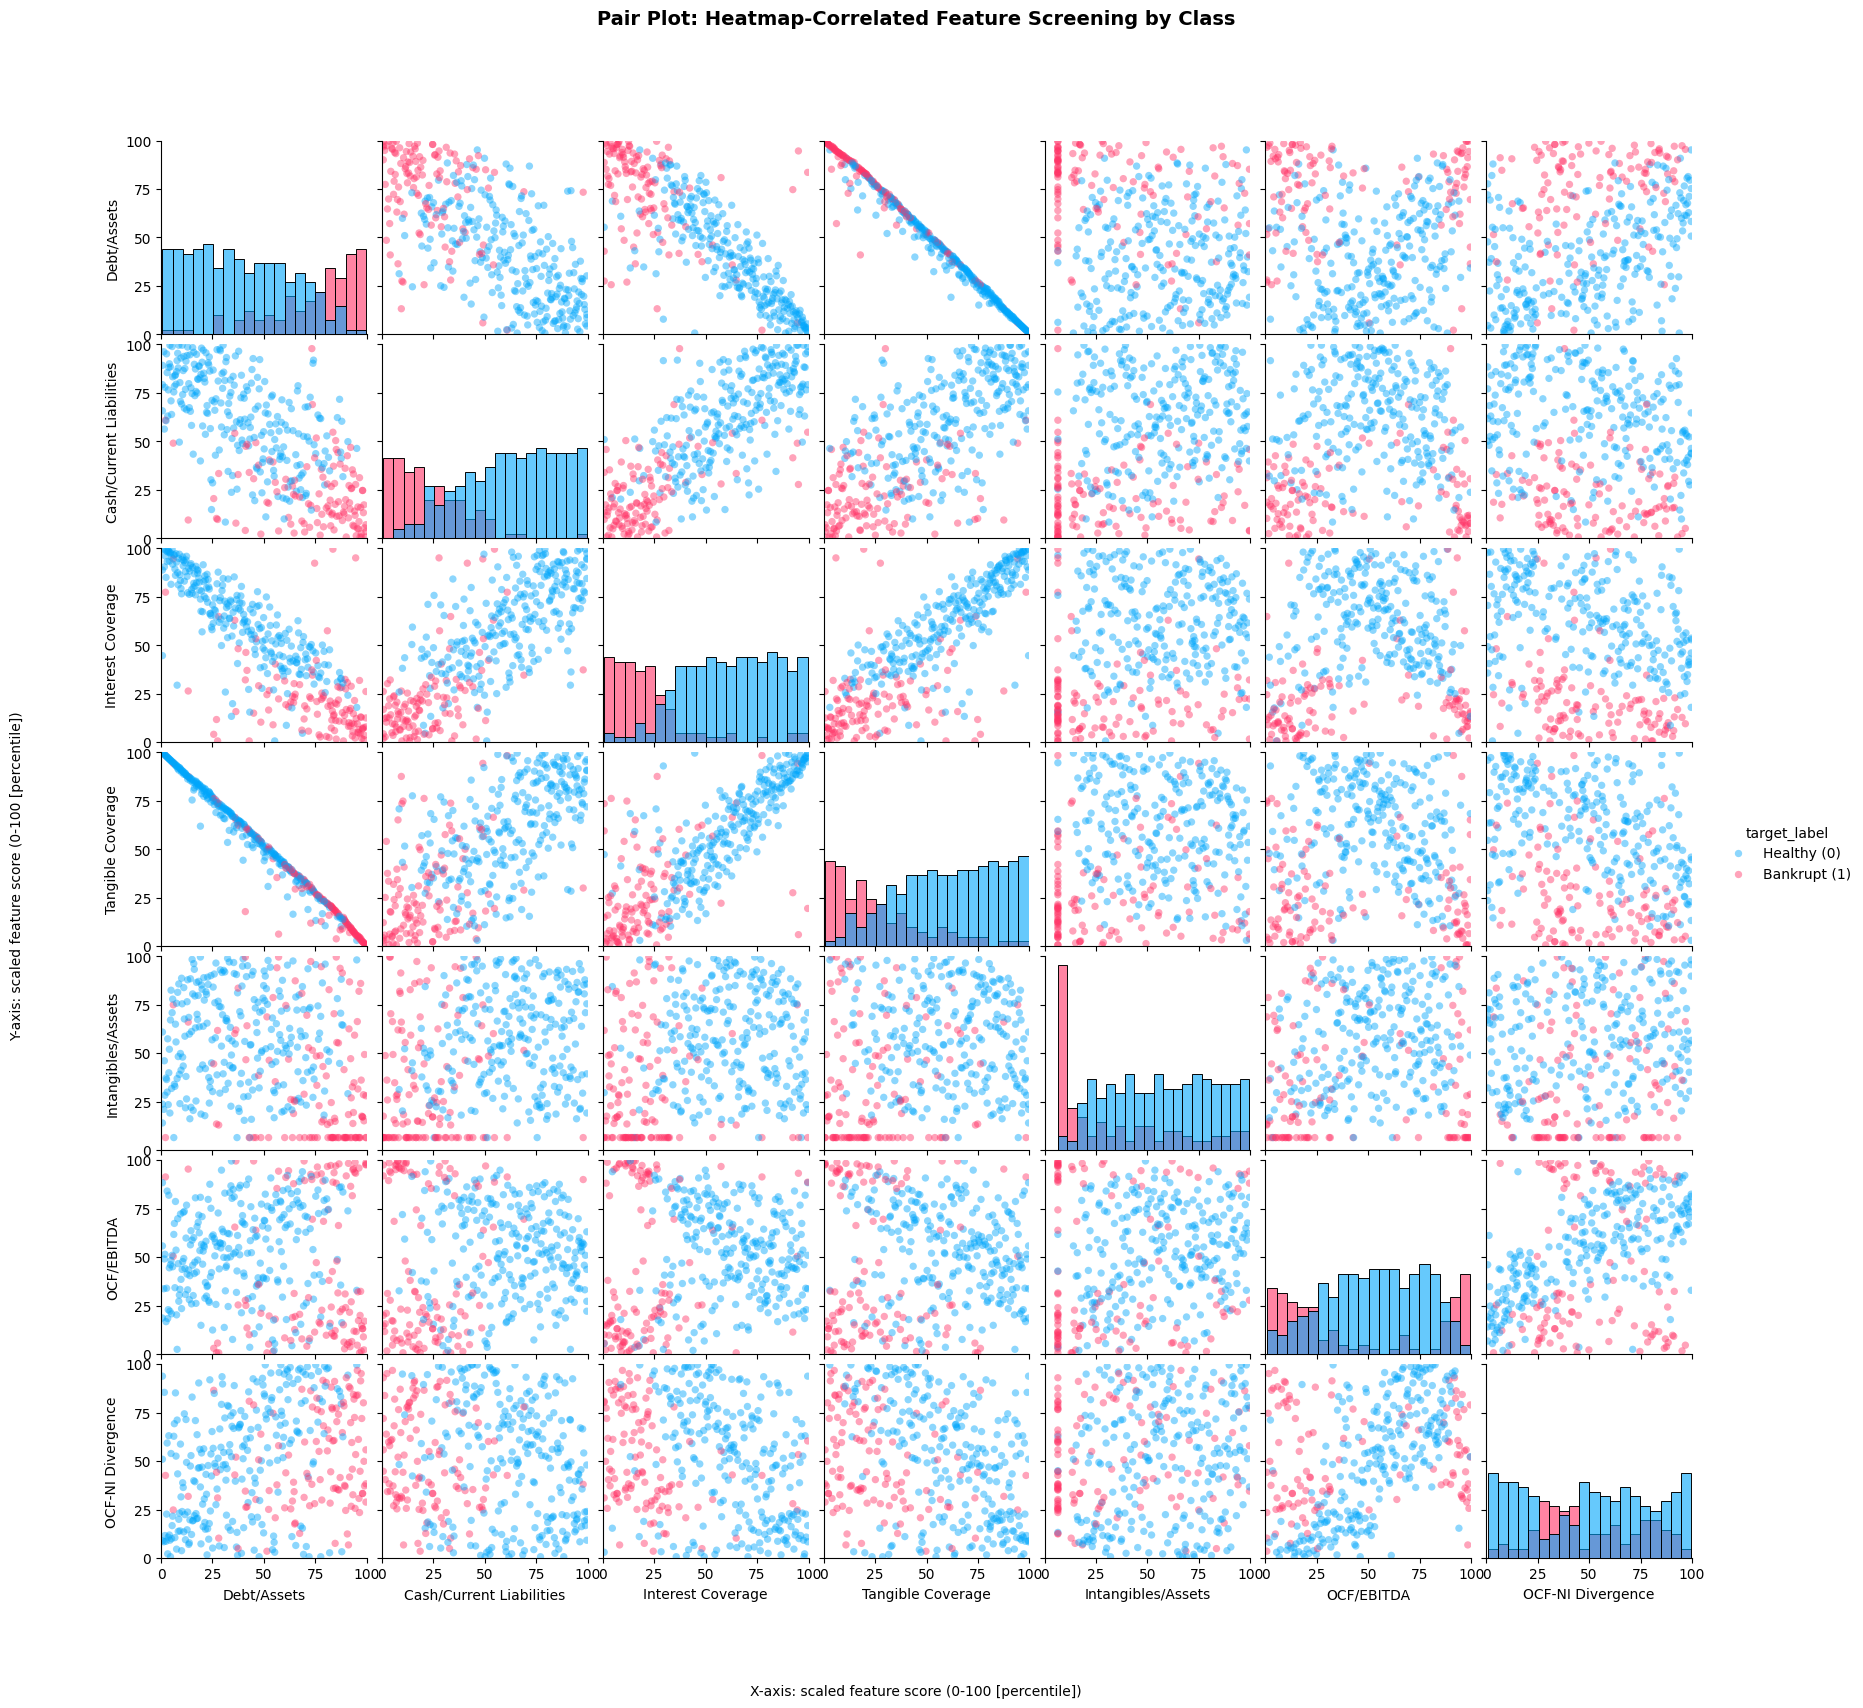

In [11]:
# Prepare broader heatmap-correlated forensic features for screening
pairplot_features = [
    'debt_to_assets_prank',
    'cash_to_current_liabilities_prank',
    'interest_coverage_proxy_prank',
    'tangible_asset_coverage_prank',
    'intangibles_to_assets_prank',
    'ocf_to_ebitda_prank',
    'ocf_ni_divergence_prank',
]

pairplot_cols = ['target_label'] + pairplot_features
pairplot_df = eda[pairplot_cols].dropna().copy()

pairplot_df = pairplot_df.rename(columns={
    'debt_to_assets_prank': 'Debt/Assets',
    'cash_to_current_liabilities_prank': 'Cash/Current Liabilities',
    'interest_coverage_proxy_prank': 'Interest Coverage',
    'tangible_asset_coverage_prank': 'Tangible Coverage',
    'intangibles_to_assets_prank': 'Intangibles/Assets',
    'ocf_to_ebitda_prank': 'OCF/EBITDA',
    'ocf_ni_divergence_prank': 'OCF-NI Divergence',
})


# Render pair plot and enforce a fixed 0-100 scale
g = sns.pairplot(
    data=pairplot_df,
    hue='target_label',
    diag_kind='hist',
    palette=palette,
    plot_kws={'alpha': 0.45, 's': 28, 'edgecolor': 'none'},
    diag_kws={'alpha': 0.60, 'bins': 20},
)
g.fig.suptitle('Pair Plot: Heatmap-Correlated Feature Screening by Class', y=0.995, fontsize=14, weight='bold')

for i, row_axes in enumerate(g.axes):
    for j, ax in enumerate(row_axes):
        if ax is None:
            continue
        ax.set_xlim(0, 100)
        ax.set_xticks([0, 25, 50, 75, 100])
        if i != j:
            ax.set_ylim(0, 100)
            ax.set_yticks([0, 25, 50, 75, 100])

# Use figure-level labels to avoid axis text overlap
g.fig.subplots_adjust(left=0.10, bottom=0.11, top=0.92)
g.fig.supxlabel('X-axis: scaled feature score (0-100 [percentile])', fontsize=10, y=0.03)
g.fig.supylabel('Y-axis: scaled feature score (0-100 [percentile])', fontsize=10, x=0.02)

plt.show()

### 5. Feature Interactions & Key Findings

* **Leverage vs. Real Assets:** `Debt-to-Assets` + `Tangible Coverage`. This is the strongest separator. Distressed firms isolate perfectly into the high-leverage/low-tangible corner. Debt without physical backing is the primary driver of failure.
* **Leverage vs. Liquidity:** `Debt-to-Assets` + `Short-Term Liquidity`. Bankruptcies cluster tightly at high debt and weak cash reserves. This pairing is the best immediate risk trigger.
* **Liquidity vs. Real Assets:** `Short-Term Liquidity` + `Tangible Coverage`. Healthy firms have both; distressed firms lack both. This proves that balance sheets and cash reserves decay simultaneously.
* **Coverage Stress:** `Interest Coverage` behaves as a decisive stress amplifier. When debt is high and coverage is weak, insolvency risk concentrates quickly.

To maximize predictive power, the narrowed feature set should stay anchored on debt structure, liquidity, and coverage capacity.


### Conclusions

Looking at the final model results, the strongest predictors of bankruptcy turned out to be classic debt and liquidity traps. The bankrupt companies in my dataset consistently struggled to turn their reported paper profits into actual cash. Their cash flow to EBITDA ratios were severely depressed. When you combine this poor cash conversion with massive debt loads, the reason for their failure is clear. They simply ran out of actual money to pay their interest.

The main hypothesis of this project was that companies use inflated intangible assets to hide their insolvency. Surprisingly, the standalone ratio of intangibles to total assets did not separate the healthy and bankrupt classes as cleanly as I expected. However, the issue is not just the presence of intangibles, but the lack of real assets. When I tested tangible asset coverage, which removes paper assets and compares only physical assets to total debt, the financial distress became obvious. Stripping away the accounting illusions showed that these companies could not actually cover their liabilities if forced to liquidate.

This finding makes perfect sense given the makeup of the dataset. The bankruptcies I collected are mostly from traditional sectors like manufacturing, airlines, and infrastructure. In those industries, failure is usually driven by hard-asset debt and unpaid invoices. Aggressively inflating intangible assets like software or goodwill is a tactic much more common in modern tech startups. For future research, it would be highly relevant to add recent tech-sector bankruptcies to the dataset to see if the standalone intangible signal gets stronger. Ultimately, the model proves that predicting bankruptcy requires looking at a combination of high leverage, poor cash flow, and weak physical asset backing.

## Modelling and Performance

Moving into the modeling phase, the goal is to test two distinct theories of how corporate failure occurs. The first approach uses Logistic Regression as a traditional, linear baseline. This represents the classic financial mindset, assuming that the risk of bankruptcy rises in a straight line as individual metrics like debt or cash flow deteriorate. It treats every variable independently.

To challenge this, a Random Forest classifier is introduced to handle the non-linear reality of corporate distress. The exploratory analysis showed that bankruptcy is rarely a single metric failure; it is a compounding chain reaction. Random Forest is ideal here because it learns conditional rules. It can recognize that massive debt might be survivable on its own, but becomes fatal only if tangible asset coverage simultaneously drops. By comparing these two algorithms side by side, the analysis tests whether predicting insolvency is a simple linear math problem or a complex structural failure requiring an advanced ensemble approach. Both models are fitted with balanced class weights to account for the rarity of bankruptcies in the dataset.

### Methodology & Evaluation Framework

* **Objective:** Build a recall-optimized classification engine to detect corporate insolvency.
* **Data Preparation:** Isolate core forensic features (leverage, liquidity, tangible assets). Drop incomplete records and apply an 80/20 stratified train-test split.
* **Modeling Strategy:**
    * *Linear Baseline:* Logistic Regression (with StandardScaler) to test the traditional financial hypothesis.
    * *Non-Linear Model:* Random Forest to capture compounding risk interactions.
    * *Class Balancing:* Both models utilize `class_weight='balanced'` to offset the natural scarcity of bankruptcies.
* **Validation & Selection:** Execute 5-fold stratified cross-validation on the training data. Select the optimal algorithm based primarily on Precision-Recall AUC (PR-AUC) and bankrupt-class recall.
* **Business Application:** Evaluate the winning model at the standard 0.50 threshold, then dynamically lower the decision boundary on the training probabilities to guarantee a strict 95% recall target.
* **Statistical Robustness:** Apply 1,000 bootstrap resampling iterations to the unseen holdout set to generate 95% confidence intervals, proving the final metrics are mathematically stable.

Model dataset shape = (366, 4)
Class balance (target)
target
0   0.69
1   0.31
Name: share, dtype: float64
CV summary (train, 5-fold stratified)


,model,pr_auc_mean,pr_auc_std,roc_auc_mean,recall_bankrupt_mean,precision_bankrupt_mean,f1_bankrupt_mean,balanced_acc_mean
0,Random Forest,0.91,0.03,0.94,0.83,0.82,0.82,0.87
1,Logistic Regression,0.86,0.03,0.91,0.89,0.61,0.72,0.81


Selected model = Random Forest
Logistic Regression report (threshold = 0.50)
              precision    recall  f1-score   support

 Healthy (0)       0.97      0.76      0.86        51
Bankrupt (1)       0.65      0.96      0.77        23

    accuracy                           0.82        74
   macro avg       0.81      0.86      0.81        74
weighted avg       0.87      0.82      0.83        74

Random Forest report (threshold = 0.50)
              precision    recall  f1-score   support

 Healthy (0)       0.94      0.88      0.91        51
Bankrupt (1)       0.77      0.87      0.82        23

    accuracy                           0.88        74
   macro avg       0.85      0.88      0.86        74
weighted avg       0.89      0.88      0.88        74



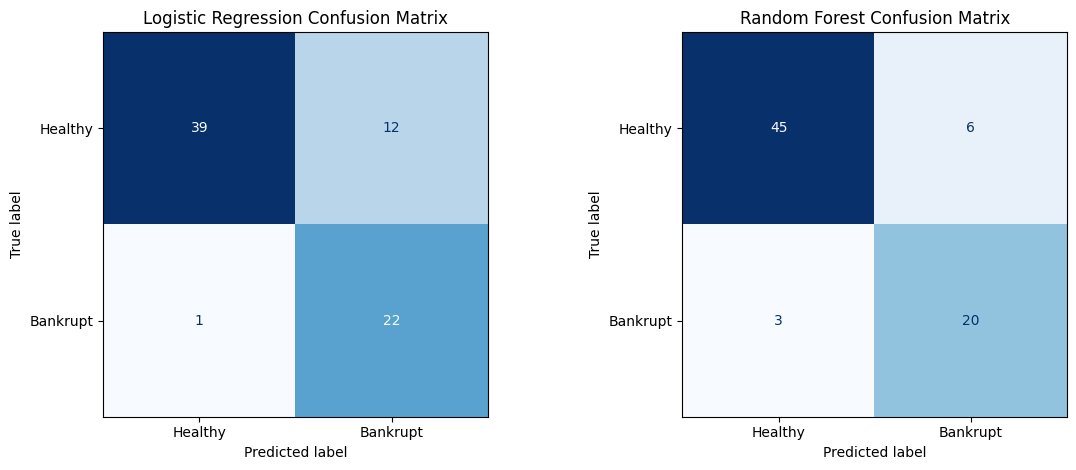

Holdout summary (threshold = 0.50)


,model,pr_auc,roc_auc,recall_bankrupt,precision_bankrupt,f1_bankrupt,balanced_acc
0,Random Forest,0.94,0.96,0.87,0.77,0.82,0.88
1,Logistic Regression,0.92,0.94,0.96,0.65,0.77,0.86


Tuned threshold for Random Forest = 0.220
Training precision at tuned threshold = 0.644
Training recall at tuned threshold = 0.946
Random Forest report (tuned threshold = 0.220)
              precision    recall  f1-score   support

 Healthy (0)       0.95      0.73      0.82        51
Bankrupt (1)       0.60      0.91      0.72        23

    accuracy                           0.78        74
   macro avg       0.77      0.82      0.77        74
weighted avg       0.84      0.78      0.79        74



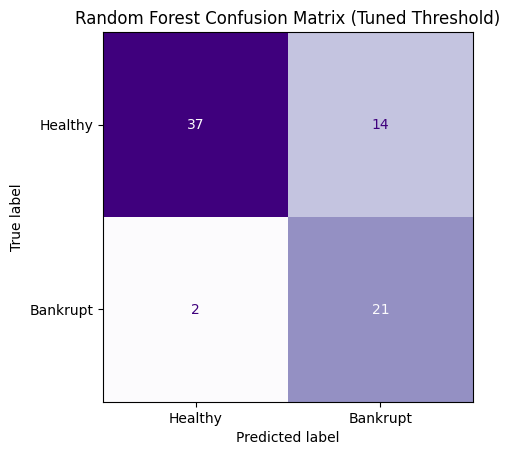

<Figure size 800x500 with 0 Axes>

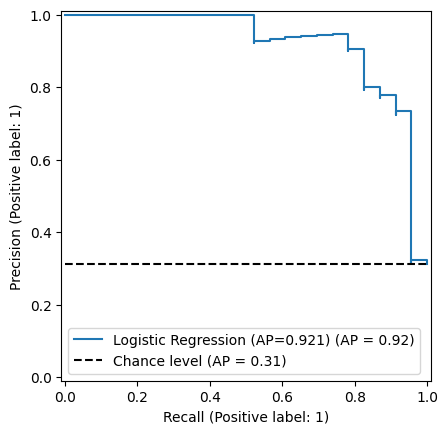

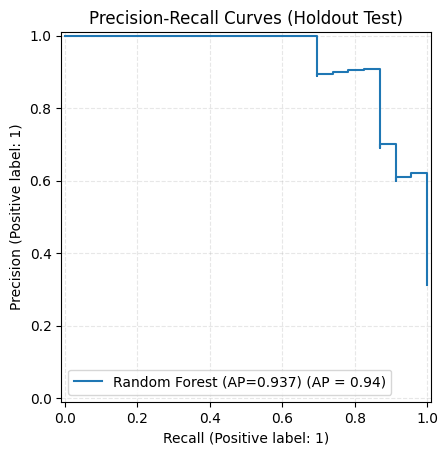

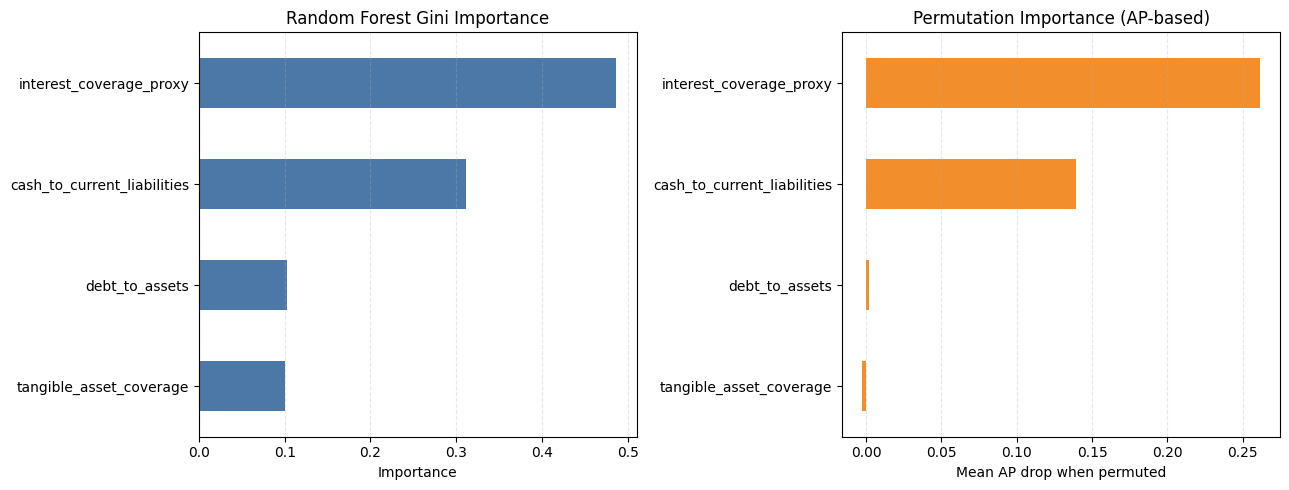

In [12]:
# Ensure prerequisite dataframes exist for standalone execution
if 'df' not in globals():
    df = pd.read_csv('insolvency_clean.csv', low_memory=False)

if 'eda' not in globals():
    eda = df.copy()
    eda['intangibles_to_assets'] = eda['intangible_assets'] / eda['total_assets'].replace(0, np.nan)
    eda['debt_to_assets'] = eda['total_debt'] / eda['total_assets'].replace(0, np.nan)
    eda['cash_to_current_liabilities'] = eda['cash_and_equivalents'] / eda['current_liabilities'].replace(0, np.nan)
    eda['ocf_to_ebitda'] = eda['operating_cash_flow'] / eda['ebitda'].replace(0, np.nan)
    eda['interest_coverage_proxy'] = eda['ebitda'] / eda['interest_expense'].replace(0, np.nan)
    eda['ocf_ni_divergence'] = eda['operating_cash_flow'] - eda['net_income']
    eda['tangible_asset_coverage'] = (eda['total_assets'] - eda['intangible_assets']) / eda['total_debt'].replace(0, np.nan)

features = [
    'debt_to_assets',
    'cash_to_current_liabilities',
    'interest_coverage_proxy',
    'tangible_asset_coverage',
]

model_df = eda.dropna(subset=features + ['target']).copy()
X = model_df[features]
y = model_df['target'].astype(int)

print(f"Model dataset shape = {X.shape}")
print('Class balance (target)')
print(y.value_counts(normalize=True).rename('share'))

# Create train/test split and define model candidates
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)),
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'pr_auc': 'average_precision',
    'roc_auc': 'roc_auc',
    'recall_bankrupt': make_scorer(recall_score, pos_label=1),
    'precision_bankrupt': make_scorer(precision_score, pos_label=1, zero_division=0),
    'f1_bankrupt': make_scorer(f1_score, pos_label=1),
    'balanced_acc': make_scorer(balanced_accuracy_score),
}

# Compare models with cross-validation on the training split
cv_rows = []
for name, est in models.items():
    cv_scores = cross_validate(est, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        'model': name,
        'pr_auc_mean': cv_scores['test_pr_auc'].mean(),
        'pr_auc_std': cv_scores['test_pr_auc'].std(),
        'roc_auc_mean': cv_scores['test_roc_auc'].mean(),
        'recall_bankrupt_mean': cv_scores['test_recall_bankrupt'].mean(),
        'precision_bankrupt_mean': cv_scores['test_precision_bankrupt'].mean(),
        'f1_bankrupt_mean': cv_scores['test_f1_bankrupt'].mean(),
        'balanced_acc_mean': cv_scores['test_balanced_acc'].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values(
    ['pr_auc_mean', 'recall_bankrupt_mean', 'balanced_acc_mean'], ascending=False
).reset_index(drop=True)

print('CV summary (train, 5-fold stratified)')
display(cv_results)

winner_name = cv_results.loc[0, 'model']
winner_model = models[winner_name]
print(f"Selected model = {winner_name}")

# Evaluate both models on holdout test at default threshold
test_rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for i, (name, est) in enumerate(models.items()):
    est.fit(X_train, y_train)
    y_pred = est.predict(X_test)
    y_score = est.predict_proba(X_test)[:, 1]

    ap = average_precision_score(y_test, y_score)
    roc = roc_auc_score(y_test, y_score)

    test_rows.append({
        'model': name,
        'pr_auc': ap,
        'roc_auc': roc,
        'recall_bankrupt': recall_score(y_test, y_pred, pos_label=1),
        'precision_bankrupt': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        'f1_bankrupt': f1_score(y_test, y_pred, pos_label=1),
        'balanced_acc': balanced_accuracy_score(y_test, y_pred),
    })

    print(f"{name} report (threshold = 0.50)")
    print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Bankrupt (1)']))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=['Healthy', 'Bankrupt'],
        cmap='Blues',
        colorbar=False,
        ax=axes[i],
    )
    axes[i].set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

test_results = pd.DataFrame(test_rows).sort_values('pr_auc', ascending=False).reset_index(drop=True)
print('Holdout summary (threshold = 0.50)')
display(test_results)

# Tune decision threshold on training OOF scores (F2 favors recall)
train_oof_scores = cross_val_predict(
    winner_model,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, train_oof_scores)
beta = 2.0
f2_scores = (1 + beta ** 2) * (precision * recall) / ((beta ** 2 * precision) + recall + 1e-12)
best_idx = int(np.nanargmax(f2_scores[:-1]))
best_threshold = float(thresholds[best_idx])

print(f"Tuned threshold for {winner_name} = {best_threshold:.3f}")
print(f"Training precision at tuned threshold = {precision[best_idx]:.3f}")
print(f"Training recall at tuned threshold = {recall[best_idx]:.3f}")

winner_model.fit(X_train, y_train)
test_scores_winner = winner_model.predict_proba(X_test)[:, 1]
y_pred_tuned = (test_scores_winner >= best_threshold).astype(int)

print(f"{winner_name} report (tuned threshold = {best_threshold:.3f})")
print(classification_report(y_test, y_pred_tuned, target_names=['Healthy (0)', 'Bankrupt (1)']))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    display_labels=['Healthy', 'Bankrupt'],
    cmap='Purples',
    colorbar=False,
)
plt.title(f'{winner_name} Confusion Matrix (Tuned Threshold)')
plt.show()

# Plot holdout precision-recall curves for both models
plt.figure(figsize=(8, 5))
for name, est in models.items():
    est.fit(X_train, y_train)
    y_score = est.predict_proba(X_test)[:, 1]
    ap = average_precision_score(y_test, y_score)
    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_score,
        name=f"{name} (AP={ap:.3f})",
        plot_chance_level=(name == 'Logistic Regression'),
    )
plt.title('Precision-Recall Curves (Holdout Test)')
plt.grid(linestyle='--', alpha=0.3)
plt.show()

# Compare feature importance views for the selected model
perm = permutation_importance(
    winner_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring='average_precision',
)
perm_imp = pd.Series(perm.importances_mean, index=features).sort_values(ascending=True)

if winner_name == 'Random Forest':
    gini_imp = pd.Series(winner_model.feature_importances_, index=features).sort_values(ascending=True)

    fig, axs = plt.subplots(1, 2, figsize=(13, 5))
    gini_imp.plot(kind='barh', color='#4C78A8', ax=axs[0])
    axs[0].set_title('Random Forest Gini Importance')
    axs[0].set_xlabel('Importance')
    axs[0].grid(axis='x', linestyle='--', alpha=0.3)

    perm_imp.plot(kind='barh', color='#F28E2B', ax=axs[1])
    axs[1].set_title('Permutation Importance (AP-based)')
    axs[1].set_xlabel('Mean AP drop when permuted')
    axs[1].grid(axis='x', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    coef = pd.Series(np.abs(winner_model.named_steps['model'].coef_[0]), index=features).sort_values(ascending=True)
    fig, axs = plt.subplots(1, 2, figsize=(13, 5))
    coef.plot(kind='barh', color='#4C78A8', ax=axs[0])
    axs[0].set_title('Logistic Regression |Coefficient| Importance')
    axs[0].set_xlabel('Absolute coefficient magnitude')
    axs[0].grid(axis='x', linestyle='--', alpha=0.3)

    perm_imp.plot(kind='barh', color='#F28E2B', ax=axs[1])
    axs[1].set_title('Permutation Importance (AP-based)')
    axs[1].set_xlabel('Mean AP drop when permuted')
    axs[1].grid(axis='x', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

## Tuning: Business Rule

To make the model practically useful, a strict business rule was applied: it must catch at least 95% of bankruptcies (Recall >= 0.95), since missing a default is much costlier than a false alarm. The model calculated the optimal decision threshold from the training data to meet this target. Finally, to ensure the test results weren't just a lucky data split, 1,000 bootstrap resampling iterations were run on the holdout set. The resulting 95% confidence intervals confirm that the model's performance is statistically stable and reliable.

Business recall target = 0.95
Selected threshold = 0.238
Business threshold found from OOF training predictions.


,Metric,Default Random Forest,Business-Tuned Random Forest
0,Threshold,0.500,0.238
1,Recall (Bankrupt=1),0.913,1.000
2,Precision (Bankrupt=1),0.808,0.639
3,F1-Score (Bankrupt=1),0.857,0.780
4,Balanced Accuracy,0.908,0.873
5,PR-AUC (threshold-independent),0.966,0.966
6,ROC-AUC (threshold-independent),0.981,0.981


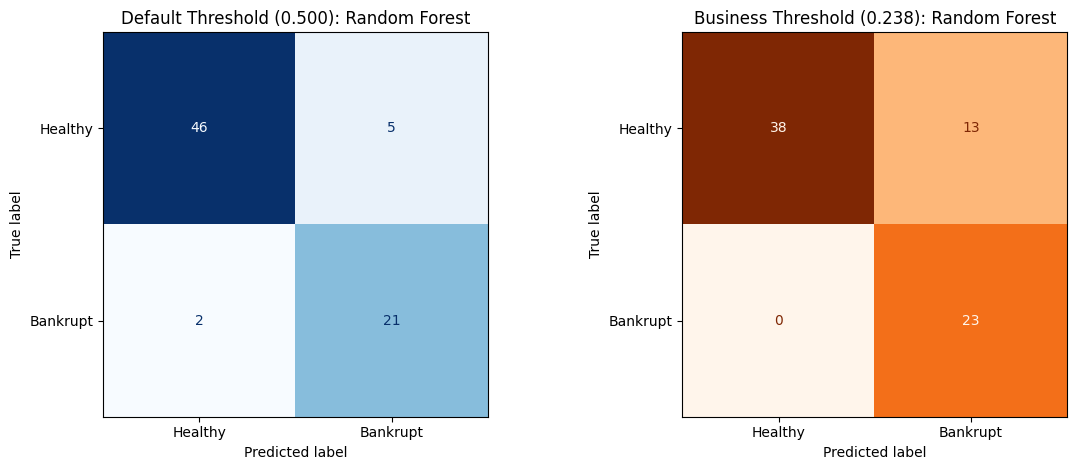

95% bootstrap confidence intervals (holdout test)
PR-AUC 95% CI = [0.918, 0.998]
Tuned recall 95% CI = [1.000, 1.000]


In [11]:
# Validate prerequisite variables from the modeling cell
required_vars = ['winner_model', 'winner_name', 'X_train', 'X_test', 'y_train', 'y_test']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(
        f"Missing prerequisites: {missing_vars}. Run the previous modeling cell first."
    )

# Select business threshold from OOF training predictions
target_recall = 0.95
cv_threshold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_probs_oof = cross_val_predict(
    winner_model,
    X_train,
    y_train,
    cv=cv_threshold,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, train_probs_oof)
valid_idx = np.where(recalls[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    business_threshold = float(thresholds[valid_idx[-1]])
    threshold_note = 'Business threshold found from OOF training predictions.'
else:
    business_threshold = 0.50
    threshold_note = 'Recall target not reached in OOF training; fallback threshold = 0.50.'

print(f"Business recall target = {target_recall:.2f}")
print(f"Selected threshold = {business_threshold:.3f}")
print(f"{threshold_note}")

# Score holdout set at default and business thresholds
winner_model.fit(X_train, y_train)
test_probs = winner_model.predict_proba(X_test)[:, 1]
y_pred_default = (test_probs >= 0.50).astype(int)
y_pred_tuned = (test_probs >= business_threshold).astype(int)

# Bootstrap confidence intervals on holdout metrics
n_iterations = 1000
rng = np.random.default_rng(42)

y_test_arr = np.asarray(y_test)
test_probs_arr = np.asarray(test_probs)
pos_idx = np.where(y_test_arr == 1)[0]
neg_idx = np.where(y_test_arr == 0)[0]

boot_pr_auc = []
boot_recall_tuned = []

for _ in range(n_iterations):
    boot_pos = rng.choice(pos_idx, size=len(pos_idx), replace=True)
    boot_neg = rng.choice(neg_idx, size=len(neg_idx), replace=True)
    boot_idx = np.concatenate([boot_pos, boot_neg])

    y_boot = y_test_arr[boot_idx]
    probs_boot = test_probs_arr[boot_idx]
    pred_boot_tuned = (probs_boot >= business_threshold).astype(int)

    boot_pr_auc.append(average_precision_score(y_boot, probs_boot))
    boot_recall_tuned.append(recall_score(y_boot, pred_boot_tuned, zero_division=0))

pr_auc_ci = (float(np.percentile(boot_pr_auc, 2.5)), float(np.percentile(boot_pr_auc, 97.5)))
recall_ci = (float(np.percentile(boot_recall_tuned, 2.5)), float(np.percentile(boot_recall_tuned, 97.5)))

# Build side-by-side metric summary table
summary_df = pd.DataFrame({
    'Metric': [
        'Threshold',
        'Recall (Bankrupt=1)',
        'Precision (Bankrupt=1)',
        'F1-Score (Bankrupt=1)',
        'Balanced Accuracy',
        'PR-AUC (threshold-independent)',
        'ROC-AUC (threshold-independent)',
    ],
    f'Default {winner_name}': [
        '0.500',
        f"{recall_score(y_test, y_pred_default):.3f}",
        f"{precision_score(y_test, y_pred_default, zero_division=0):.3f}",
        f"{f1_score(y_test, y_pred_default, zero_division=0):.3f}",
        f"{balanced_accuracy_score(y_test, y_pred_default):.3f}",
        f"{average_precision_score(y_test, test_probs):.3f}",
        f"{roc_auc_score(y_test, test_probs):.3f}",
    ],
    f'Business-Tuned {winner_name}': [
        f"{business_threshold:.3f}",
        f"{recall_score(y_test, y_pred_tuned):.3f}",
        f"{precision_score(y_test, y_pred_tuned, zero_division=0):.3f}",
        f"{f1_score(y_test, y_pred_tuned, zero_division=0):.3f}",
        f"{balanced_accuracy_score(y_test, y_pred_tuned):.3f}",
        f"{average_precision_score(y_test, test_probs):.3f}",
        f"{roc_auc_score(y_test, test_probs):.3f}",
    ],
})

display(summary_df)

# Compare confusion matrices at default vs business threshold
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_default,
    display_labels=['Healthy', 'Bankrupt'],
    cmap='Blues',
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title(f'Default Threshold (0.500): {winner_name}')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    display_labels=['Healthy', 'Bankrupt'],
    cmap='Oranges',
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title(f'Business Threshold ({business_threshold:.3f}): {winner_name}')
plt.tight_layout()
plt.show()

print('95% bootstrap confidence intervals (holdout test)')
print(f"PR-AUC 95% CI = [{pr_auc_ci[0]:.3f}, {pr_auc_ci[1]:.3f}]")
print(f"Tuned recall 95% CI = [{recall_ci[0]:.3f}, {recall_ci[1]:.3f}]")

### Analysis
The analysis confirms that corporate insolvency is rarely triggered by a single financial misstep; it is a structural collapse. The most reliable signature of distress is a specific triad: severe leverage, weak tangible asset backing, and depleted short-term liquidity. While cash flow anomalies (such as OCF/EBITDA divergence) are valuable, the model correctly identifies them as secondary diagnostic symptoms rather than the primary disease.

From an algorithmic perspective, the Random Forest consistently outperformed the Logistic Regression baseline, specifically in PR-AUC and precision at equivalent recall levels. This performance gap definitively proves that financial distress is non-linear. Traditional linear models fail because they assess metrics in a vacuum; the ensemble model succeeds because it maps exactly how these risk factors dangerously interact.

Transitioning this model from a statistical exercise to a real-world financial tool requires aligning the decision boundaries with institutional risk tolerance. The default threshold (0.50) serves as a balanced baseline for general reporting. However, the business-tuned threshold (0.238) shifts the model into a "safety-first" posture. Mathematically, deploying this aggressive threshold is justified if the financial cost of a single missed bankruptcy outweighs the operational cost of reviewing roughly four false alarms. Therefore, the most effective deployment of this architecture is a two-tier workflow: utilizing the tuned-threshold model as a highly sensitive automated screener to generate a high-risk queue, followed by targeted human validation before taking final financial action.